### **[A]: Choice of a population, with supporting expenditure data**

In [1]:
!pip install -r requirements.txt

In [2]:
#Importing
%pip install python-gnupg
%pip install eep153_tools
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import eep153_tools

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
#Prices
ugd2_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2009-10).csv')
ugd2_p0 = ugd2_p0[ugd2_p0["u"] == "Kg"]
ugd2_p = pd.pivot_table(ugd2_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd2_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2009-10).csv')
ugd2_x0['i'] = ugd2_x0['i'].astype(str)
ugd2_x = pd.pivot_table(ugd2_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd2_x_long = ugd2_x.stack().reset_index(name="Expenditure")  # Ensure values are in a column
ugd2_p_long = ugd2_p0
ugd2_c = ugd2_x_long.merge(ugd2_p_long, on=["j", "t", "m"], how="left")
ugd2_c["Consumption"] = ugd2_c["Expenditure"] / ugd2_c["price"]
ugd2_c = ugd2_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z0 = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd2_z = ugd_z0[ugd_z0['t'] == '2009-10']
ugd2_z = ugd2_z.set_index(['i','t','m'])
ugd2_z.columns.name = 'k'
ugd2_z.fillna(0, inplace=True)

### **[B]: Nutritional content of different foods**

In [4]:
#FCT
ugd_fct = pd.read_csv('Data Files/Uganda - FCT.csv')
ugd_fct = ugd_fct.rename(columns={"index":"j"}).set_index(["j"])
ugd_fct.columns.name = 'n'
#RDI
ugd_rdi = pd.read_csv('Data Files/Uganda - RDA.csv')
ugd_rdi = ugd_rdi.set_index(["n"])
ugd_rdi.columns.name = 'k'

### **[A]: Estimate demand system**

In [5]:
import cfe
from cfe import Regression

ugd2_result = cfe.Regression(y=np.log(ugd2_x.stack()),d=ugd2_z)

In [6]:
ugd2_result.predicted_expenditures()

i           t        m        j                     
1013000201  2009-10  Central  Beans (dry)                2694.464062
                              Beans (fresh)              2320.464473
                              Beef                       5272.890931
                              Bread                      3087.068336
                              Cabbage (green)             737.245818
                                                            ...     
4193003510  2009-10  Western  Sugar                      5540.817719
                              Sweet Bananas              5210.154727
                              Sweet Potatoes (fresh)    15129.533657
                              Tea                         724.369893
                              Tomatoes                   2288.366398
Length: 98864, dtype: float64

<Axes: xlabel='yhat', ylabel='y'>

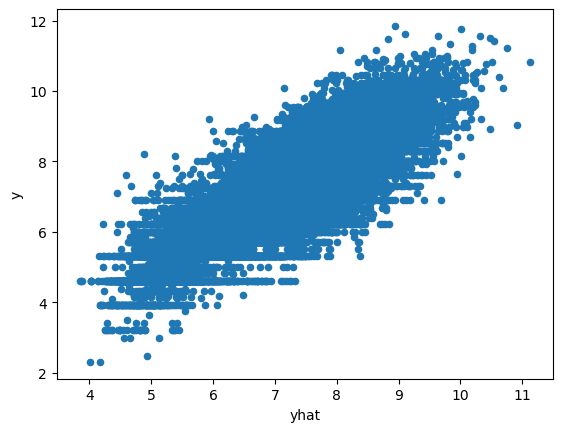

In [7]:
#Expenditures x may have duplicate columns
x1 = ugd2_x0.groupby(['i','t','m','j']).sum()
#Replace zeros with missing values
x1 = x1.replace(0,np.nan)
#Take logs of expenditures; call this y
y = np.log(x1["Expenditure"])
#Create dataframe with predicted yhat values
ugd2_acc = pd.DataFrame({'y':y,'yhat':ugd2_result.get_predicted_log_expenditures()})
#Plot yhat vs y (predicted vs actual)
ugd2_acc.plot.scatter(x='yhat',y='y')

In [8]:
#Proportion of variance in the dependent variable that can be explained by the independent variable
ugd2_result.R2(summary=True)

np.float64(0.720938941892072)

In [9]:
#Save result
ugd2_result.to_pickle('./Uganda09-10.rgsn')
##To access result:
#import cfe
#result = cfe.regression.read_pickle('Uganda09-10.rgsn')

### Parameters

**(Relative) Income Elasticity:** $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.
Here we use a plot to visualize, with confidence intervals.

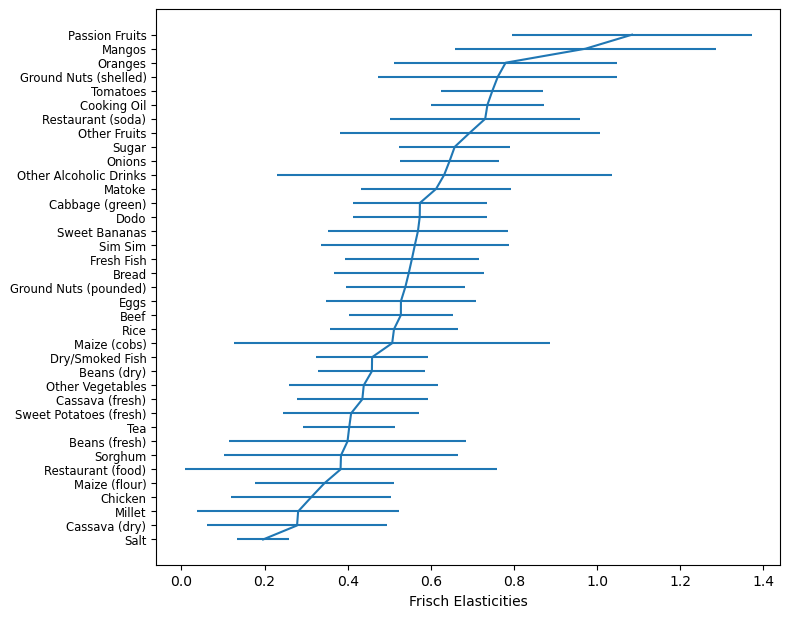

In [10]:
ax1 = ugd2_result.graph_beta()

In [11]:
ugd2_result.get_beta().sort_values(ascending=False)

j
Passion Fruits            1.083969
Mangos                    0.972214
Oranges                   0.779873
Ground Nuts (shelled)     0.761092
Tomatoes                  0.748012
Cooking Oil               0.736126
Restaurant (soda)         0.730697
Other Fruits              0.693386
Sugar                     0.657388
Onions                    0.645184
Other Alcoholic Drinks    0.631971
Matoke                    0.612514
Cabbage (green)           0.573658
Dodo                      0.573224
Sweet Bananas             0.568979
Sim Sim                   0.561483
Fresh Fish                0.554361
Bread                     0.546786
Ground Nuts (pounded)     0.538538
Eggs                      0.528006
Beef                      0.527837
Rice                      0.511323
Maize (cobs)              0.506927
Dry/Smoked Fish           0.458590
Beans (dry)               0.458139
Other Vegetables          0.438569
Cassava (fresh)           0.435123
Sweet Potatoes (fresh)    0.408178
Tea               

**Demand and Household Composition:** $\gamma_j$ parameters in the regression, which capture the effects of household composition on demand

In [12]:
ugd2_result.get_gamma()

k,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,
Beans (dry),-0.035986,-0.002196,0.011420,0.088201,0.008645,0.040896,0.076534,0.000460,0.034751,0.034270,0.039660,0.042808,0.028531,0.093562,0.428020,7.765004
Beans (fresh),-0.023585,0.041274,0.056707,0.026288,-0.047457,0.056052,0.152620,-0.093632,0.054304,-0.048272,0.088565,0.052230,0.181914,0.363833,0.346367,7.776198
Beef,-0.079653,-0.014531,0.010779,0.044428,0.174338,0.057924,0.063672,-0.018021,0.028349,0.042153,0.042880,0.116182,0.192633,0.141053,0.278426,8.518168
Bread,-0.075781,0.007562,0.055134,0.025240,0.174344,0.064483,0.012479,-0.088812,0.019160,0.020554,0.044839,0.077785,0.185478,-0.011309,0.222674,7.697521
Cabbage (green),-0.012443,-0.012222,0.067465,0.056218,0.016087,-0.058448,-0.088442,-0.018190,-0.051906,-0.044901,0.090028,0.099277,0.032054,0.101083,0.249912,6.609570
Cassava (dry),-0.016754,-0.027009,0.020894,-0.102213,-0.118994,-0.035726,0.155048,0.041686,-0.055836,0.037948,0.029962,-0.043425,0.026531,0.166427,0.705606,8.097507
Cassava (fresh),-0.024868,0.041056,0.019366,0.100339,-0.069073,-0.049137,-0.058890,0.035913,0.033114,0.073408,0.010808,0.052749,0.073114,0.095322,0.330980,7.697081
Chicken,-0.132288,-0.110416,-0.051868,-0.122507,0.105862,-0.092466,0.008650,-0.109125,-0.053229,-0.047875,-0.047422,0.062452,0.068504,-0.088127,0.669834,8.873683
Cooking Oil,-0.080042,-0.018388,0.017443,0.098008,0.159053,-0.012046,-0.091420,-0.036246,-0.022896,-0.006680,0.051703,0.121050,0.118722,-0.005265,0.223714,6.778519


**Welfare:** $w_i$ parameters, which are a welfare measure for the household.

<Axes: ylabel='Density'>

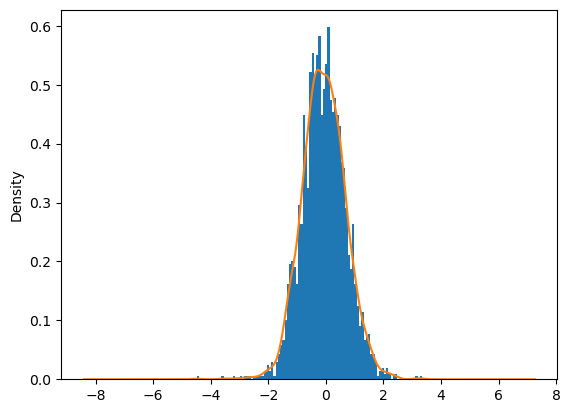

In [13]:
ax2 = ugd2_result.get_w().plot.hist(bins=100,density=True)
ugd2_result.get_w().plot.kde(ax=ax2)

### Demand and Utility

**Budgets:** Get food budget for all households, then find median budget

In [14]:
xhat = ugd2_result.predicted_expenditures()
#Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()
#Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

**Reference Prices:** Choose reference prices.  Here we chose the year 2015 and averaged prices across markets.

In [15]:
#Prices per kilogram:
pbar = ugd2_p.mean(axis=1)
pbar = pbar.reset_index(level="u", drop=True) #Reset index so that 'j' becomes a column instead of part of a MultiIndex
pbar = pbar.reindex(ugd2_result.beta.index) #Only use prices for goods we can estimate
#Replace missing prices with 1 (this is because they're best measured in expenditures)
pbar = pbar.replace(np.nan,1)
#Define a function to change a single price in the vector $p$:
def my_prices(p0,j,p=pbar):
    """
    Change price of jth good to p0, holding other prices fixed.
    """
    p = p.copy()
    p.loc[j] = p0
    return p

**Demand as a function of prices:** Demand schedules for households with different budgets

Text(0.5, 0, 'Quantities of Beef Demanded')

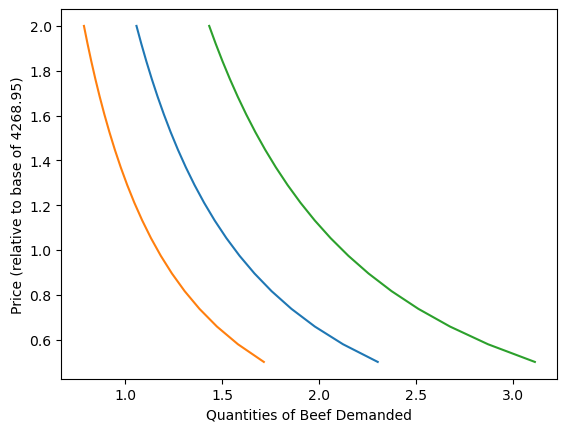

In [16]:
use = 'Beef'  #Good we want demand curve for

#Vary prices from 50% to 200% of reference.
scale = np.linspace(.5,2,20)

#Demand for Millet for household at median budget
plt.plot([ugd2_result.demands(xref,my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 25% percentile
plt.plot([ugd2_result.demands(xbar.quantile(0.25),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 75% percentile
plt.plot([ugd2_result.demands(xbar.quantile(0.75),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded")

**Engel Curves:** Tracing how demand changes with budget

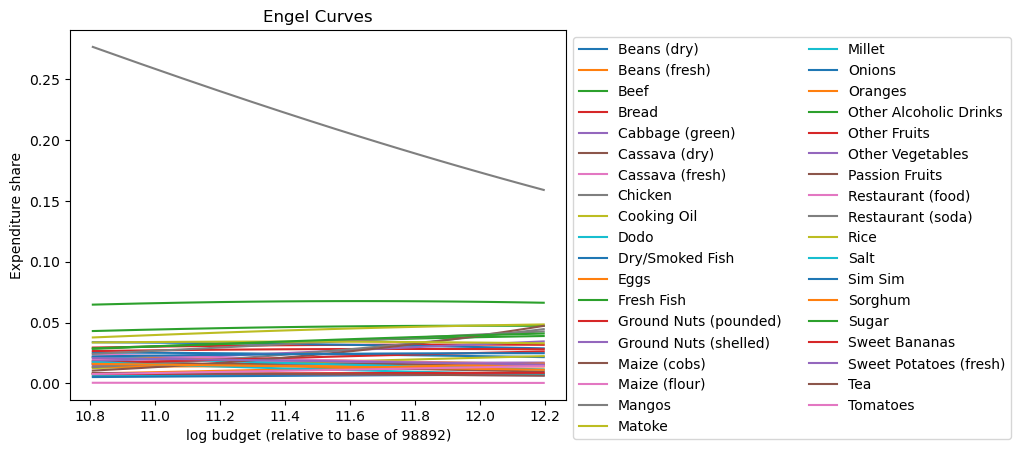

In [17]:
fig,ax = plt.subplots()

ax.plot(np.log(scale*xref),[ugd2_result.expenditures(s*xref,pbar)/(s*xref) for s in scale])
ax.set_xlabel(f'log budget (relative to base of {xref:.0f})')
ax.set_ylabel(f'Expenditure share')
ax.set_title('Engel Curves')
ax.legend(ugd2_result.expenditures(xref,pbar).index.tolist(), loc="upper left", bbox_to_anchor=(1, 1), ncol=2)

**Indirect Utility Function:**

Text(0.5, 1.0, 'Indirect Utility Function')

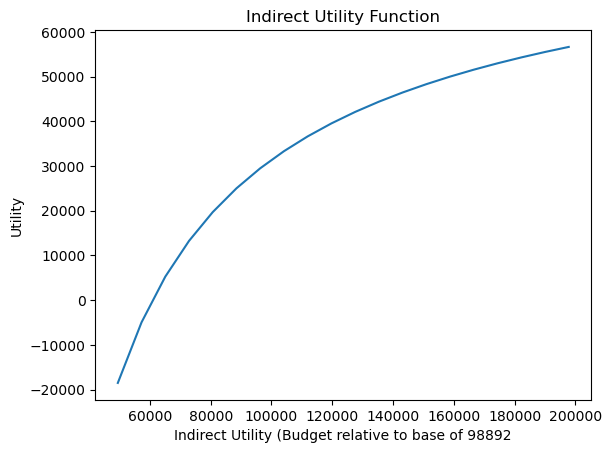

In [18]:
fig,ax = plt.subplots()

ax.plot(scale*xref,[ugd2_result.indirect_utility(s*xref,pbar) for s in scale])
ax.set_xlabel(f'Indirect Utility (Budget relative to base of {xref:.0f}')
ax.set_ylabel(f'Utility')
ax.set_title('Indirect Utility Function')

### **[B]: Nutritional adequacy of diet**

In [19]:
#Get result saved above
ugd2_result = cfe.read_pickle('Uganda09-10.rgsn')
#Quantities in kg: expenditures divided by prices/kg
qhat = (xhat.unstack('j')/ugd2_p.reset_index(drop=True, level="u").transpose()).dropna(how='all')
#Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

In [20]:
#Coluns of qhat to match fct
use = ugd_fct.index.intersection(qhat.columns)

nutrients = qhat[use]@ugd_fct.loc[use,:]
nutrients.mean()    # NB: Nutrients are for past /week/ for entire household

n
Energy          175459.404673
Protein           5833.023796
Fiber             3375.445085
Folate           45654.559971
Calcium          35739.083787
Carbohydrate     31736.602674
Iron              1342.612907
Niacin            1447.969403
Riboflavin          94.888046
Thiamin            146.218241
Vitamin A        29347.070761
Vitamin B-12       191.460155
Vitamin B-6        258.254482
Vitamin C        13619.494763
Zinc               695.372885
Magnesium            0.000000
Phosphorus           0.000000
Potassium            3.872938
Vitamin E            0.000000
Vitamin K            0.000000
dtype: float64

In [21]:
#Obtain recommended daily intake
ugd2_z = ugd2_z[ugd_rdi.columns.tolist()]
hh_rdi = ugd2_z@ugd_rdi.T
#Make this a recommended WEEKLY intake
hh_rwi = hh_rdi*7
# Match up nutrient names
use_nutrients = nutrients.columns.intersection(hh_rwi.columns)
nutrient_ratio = (nutrients[use_nutrients]/hh_rwi[use_nutrients]).dropna()
#Display
nutrient_ratio

,,n,Energy,Protein,Fiber,Folate,Calcium,Carbohydrate,Iron,Niacin,Riboflavin,Thiamin,Vitamin A,Vitamin B-12,Vitamin B-6,Vitamin C,Zinc,Magnesium,Phosphorus,Potassium,Vitamin E,Vitamin K
i,t,m,,,,,,,,,,,,,,,,,,,,
1013000201,2009-10,Central,2.207949,3.375021,2.911832,2.756413,0.729189,5.159098,2.322872,2.550427,2.344151,2.997098,0.978532,2.418490,4.766925,4.128765,1.974501,0.0,0.0,0.000023,0.0,0.0
1013000204,2009-10,Central,2.988575,5.310808,3.953616,3.987510,0.765299,5.201949,3.705961,3.632154,2.958309,4.231035,1.366381,3.122144,6.675793,7.137930,2.948800,0.0,0.0,0.000027,0.0,0.0
1013000206,2009-10,Central,7.079795,10.067098,9.094005,9.723545,3.607547,18.249870,14.263639,8.555544,7.561344,9.268509,3.248115,10.292876,15.530701,12.561071,5.541839,0.0,0.0,0.000078,0.0,0.0
101300021302,2009-10,Central,3.006002,4.413790,3.803023,3.497754,0.963304,6.492705,3.396890,3.316167,3.095021,3.716481,1.323158,3.526301,5.557569,4.746446,2.602180,0.0,0.0,0.000030,0.0,0.0
1021000102,2009-10,Central,2.839144,4.740582,3.678542,3.540509,0.729702,5.302375,3.600762,3.343236,2.905254,3.587048,1.227500,3.538383,6.095992,6.081369,2.355067,0.0,0.0,0.000023,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4193003503,2009-10,Western,2.158059,3.158320,3.306134,3.472491,0.700964,5.469436,2.758150,2.450995,2.118237,3.427653,1.086522,1.849860,5.266036,4.255366,1.932459,0.0,0.0,0.000017,0.0,0.0
4193003504,2009-10,Western,1.554146,2.259989,2.370810,2.613735,0.553819,4.189241,1.728147,1.644193,1.501584,2.652805,0.737816,1.042873,3.739618,3.090381,1.491507,0.0,0.0,0.000016,0.0,0.0
4193003506,2009-10,Western,2.535890,4.097517,4.048422,4.656592,0.732079,5.727032,3.302181,2.941543,2.406977,4.274618,1.244117,2.094293,6.136291,4.578681,2.413918,0.0,0.0,0.000018,0.0,0.0


In [22]:
#Save df
nutrient_ratio.to_csv('Nutrient Data/09-10 Nutrient Data.csv')

<Axes: >

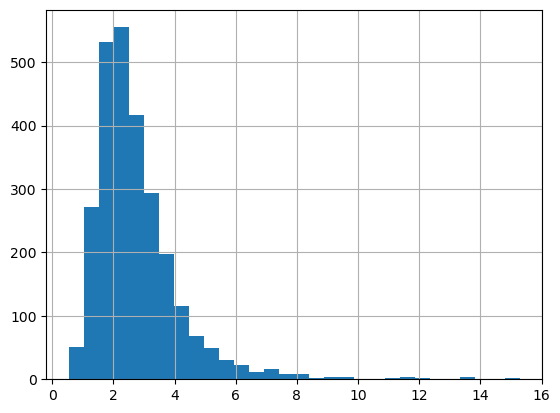

In [23]:
#Plot nutrient ratio for specific nutrient
%matplotlib inline
nutrient_ratio['Energy'].hist(bins=30)